<a href="https://colab.research.google.com/github/Chathu283/Statistical-Learning-e23218/blob/main/Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install git+https://github.com/Chathu283/Statistical-Learning-e23218.git

  Cloning https://github.com/Chathu283/Statistical-Learning-e23218.git to /tmp/pip-req-build-0be9122b
  Running command git clone --filter=blob:none --quiet https://github.com/Chathu283/Statistical-Learning-e23218.git /tmp/pip-req-build-0be9122b
  Resolved https://github.com/Chathu283/Statistical-Learning-e23218.git to commit 57a756b415e624c68015ef5297ee1f7dfa724cde
  Preparing metadata (setup.py) ... done


In [8]:
from data_inspector import DataInspector

# Initialize your tool
inspector = DataInspector()

# Trigger the upload portal
inspector.upload_data()

Saving titanic_sample.csv to titanic_sample (6).csv
✅ Successfully loaded 'titanic_sample (6).csv' (20 rows, 10 columns).


In [9]:
inspector.data_summary()

 STRUCTURAL SUMMARY: 20 Rows | 10 Columns
 Numeric Features (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
 Categorical Features (3): ['Name', 'Sex', 'Embarked']

📊 FIRST 20 ROWS PREVIEW:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,512.3292,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W",female,27.0,0,2,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas",female,14.0,1,0,30.0708,C


In [10]:
inspector.handle_missing_values(strategy='median')

✅ Missing value resolution achieved via strategy: 'median'.


In [11]:
inspector.handle_outliers(columns=['TotalCharges', 'MonthlyCharges'], action='delete')

🗑️ Dropped 0 rows containing IQR outliers.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38.0,1,0,512.3292,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
5,6,0,3,"Moran, Mr. James",male,27.0,0,0,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W",female,27.0,0,2,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas",female,14.0,1,0,30.0708,C


In [12]:
inspector.plot_all_associations_heatmap()

In [19]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Define your Target (Y) from the original dataframe (inspector.df)
# before any scaling is applied to it for the feature set.
Y = inspector.df['Survived'] # This assumes inspector.df still holds the original 0s and 1s for 'Survived'

# Extract the unified, perfectly prepared dataframe from your package
# This dataframe will have 'Survived' scaled if it's treated as a numerical feature.
cleaned_df = inspector.merge_processed_datasets(num_strategy='standard', cat_strategy='onehot')

# Define your Features (X) by dropping the potentially scaled 'Survived' from cleaned_df
X = cleaned_df.drop(columns=['Survived'])

# Identify and drop problematic columns that cause multicollinearity or perfect separation
# 1. PassengerId is an identifier, not a predictor
if 'PassengerId' in X.columns:
    X = X.drop(columns=['PassengerId'])

# 2. Drop one-hot encoded 'Name' columns (as it's an identifier and creates too many features with perfect separation)
name_cols = [col for col in X.columns if col.startswith('Name_')]
if name_cols:
    X = X.drop(columns=name_cols)

# 3. Drop one redundant column from 'Embarked' to avoid perfect multicollinearity with the intercept
# (Assuming 'Embarked_S' is chosen as the reference category to drop if it exists)
if 'Embarked_S' in X.columns:
    X = X.drop(columns=['Embarked_S'])

# 4. Drop one redundant column from 'Sex' to avoid perfect multicollinearity with the intercept
# If both 'Sex_female' and 'Sex_male' exist, one must be dropped.
if 'Sex_female' in X.columns and 'Sex_male' in X.columns:
    X = X.drop(columns=['Sex_female']) # Arbitrarily dropping 'Sex_female'

# Add intercept for statistical modeling
X = sm.add_constant(X)

# Split and fit a Statistical Learning model
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Use fit_regularized to handle perfect separation issues, with a small alpha value
# Setting alpha=0.1 to introduce L1 regularization.
model = sm.Logit(Y_train, X_train).fit_regularized(alpha=0.1)

# Print the statistical breakdown
print(model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2564615268213082
            Iterations: 67
            Function evaluations: 67
            Gradient evaluations: 67
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                   16
Model:                          Logit   Df Residuals:                        9
Method:                           MLE   Df Model:                            6
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.7560
Time:                        12:52:02   Log-Likelihood:                -2.6760
converged:                       True   LL-Null:                       -10.965
Covariance Type:            nonrobust   LLR p-value:                   0.01097
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


In [23]:
# Since both are numbers, this automatically generates a Scatter Plot with a trendline
inspector.plot_relationship('Age', 'Fare')

In [24]:
# Since both are categories, this automatically generates a Grouped Bar Chart
inspector.plot_relationship('Sex', 'Survived')

In [25]:
# This automatically generates a Box Plot showing the distribution of Fare prices by Class
inspector.plot_relationship('Pclass', 'Fare')

In [26]:
# Pass it a single numeric column
inspector.plot_univariate_subplots('Age')

In [27]:
from data_inspector.plotting import PlottingMethods

# Generate an interactive Pie Chart
PlottingMethods.generate_pie_chart(inspector.df, 'Embarked')

# Generate a standalone Bar Chart with percentages
PlottingMethods.generate_bar_chart(inspector.df, 'Pclass')

'<div>                        <script type="text/javascript">window.PlotlyConfig = {MathJaxConfig: \'local\'};</script>\n        <script charset="utf-8" src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>                <div id="0028e65a-f5be-4023-8c0c-e75cdbe3fd05" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                                    window.PLOTLYENV=window.PLOTLYENV || {};                                    if (document.getElementById("0028e65a-f5be-4023-8c0c-e75cdbe3fd05")) {                    Plotly.newPlot(                        "0028e65a-f5be-4023-8c0c-e75cdbe3fd05",                        [{"alignmentgroup":"True","hovertemplate":"Pclass=%{x}\\u003cbr\\u003eFrequency=%{y}\\u003cbr\\u003etext=%{text}\\u003cextra\\u003e\\u003c\\u002fextra\\u003e","legendgroup":"","marker":{"color":"#636efa","pattern":{"shape":""}},"name":"","offsetgroup":"","orientation":"v","showlegend":false,"text":["13.0 (65.0%)","4

In [31]:
inspector.delete_columns('Age')

✅ Successfully dropped columns: ['Age']


In [32]:
inspector.data_summary()

 STRUCTURAL SUMMARY: 20 Rows | 9 Columns
 Numeric Features (6): ['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch', 'Fare']
 Categorical Features (3): ['Name', 'Sex', 'Embarked']

📊 FIRST 20 ROWS PREVIEW:


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,1,0,512.3292,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,0,0,8.0500,S
5,6,0,3,"Moran, Mr. James",male,0,0,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,0,0,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,3,1,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W",female,0,2,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas",female,1,0,30.0708,C


### Model Evaluation

In [20]:
from sklearn.metrics import accuracy_score

# Predict probabilities on the test set
Y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
Y_pred = (Y_pred_proba > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)

print(f"Model Accuracy on Test Set: {accuracy:.4f}")

Model Accuracy on Test Set: 0.7500


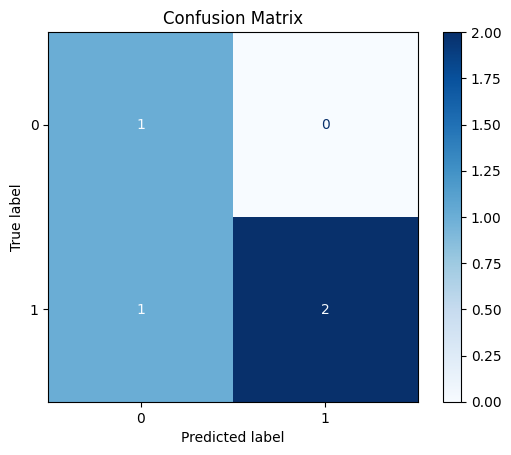

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Assuming 0 and 1 are your class labels

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [22]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(Y_test, Y_pred, target_names=['Not Survived', 'Survived'])

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.50      1.00      0.67         1
    Survived       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

